In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation, percentileofscore

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
## From Cellbender Import ##

sawada_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/studies/sawada_kato/anndata_objs/sawada_cellbendered.h5ad')

sawada_adata.obs['Run'] = [i.split('_')[0] for i in sawada_adata.obs_names]

sawada_adata.obs['barcodes'] = sawada_adata.obs_names

# filter ambient rna
sawada_adata = sawada_adata[sawada_adata.obs['cell']].copy()

In [3]:
## Merge SRA Metadata ##

## SRA MetaData Import ##

sawada_sra_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/sawada_kato_molecular_psych_2020/metadata/Sawada_SRA_RunTable.csv')

# get rid of WGS sample, keep useful cols

sawada_sra_metadata_essential = sawada_sra_metadata[['Run', 'BioProject', 'BioSample',
                                                     'Bytes', 'cultured_period',
                                                     'Experiment', 'individual', 'Instrument',
                                                     'method_name', 'ReleaseDate', 'create_date', 
                                                     'Sample Name', 'SRA Study']]

sawada_adata.obs = sawada_adata.obs.merge(sawada_sra_metadata_essential, left_on='Run', right_on='Run', how='left')

sawada_adata.obs.index = sawada_adata.obs['barcodes']

sawada_adata.obs['Donor'] = sawada_adata.obs['individual'].str.split(' ').apply(lambda x: x[0])

In [4]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
sawada_adata.var['ensembl_gene_id'] = sawada_adata.var.index
sawada_adata.var = sawada_adata.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
sawada_adata.var.chromosome_name = sawada_adata.var.chromosome_name.astype('str')

# fix gene name that is NaN
sawada_adata.var.loc[sawada_adata.var['hgnc_symbol'].isna(),'hgnc_symbol'] = sawada_adata.var.loc[sawada_adata.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
sawada_adata.var.index = sawada_adata.var['hgnc_symbol']
sawada_adata.var.index.name = None

#some ensembls map to same hgnc so we make them unique
sawada_adata.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_1332033/1860402028.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


66195

In [5]:
## Donor Metadata From Supplementary Figure 1A of Original Paper ##

sawada_donor_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/sawada_kato_molecular_psych_2020/metadata/Sawada_Donor_Metadata.csv')

In [6]:
sawada_donor_metadata

,Subjects,Diagnosis,Criteria,Age,Onset,Sex,Affected Twin,Unaffected Twin,Parental Cells for iPSC,Family History,Note
0,DT1,"Schizoaffective disorder, bipolar-type","DSM-IV, MINI",20s,20s,M,DT1_A,DT1_U,PBMCs,NaN,NaN
1,DT2,Schizophrenia,DSM-IV,50s,20s,M,DT2_A,DT2_U,LCLs,NaN,NaN
2,DT3,Schizophrenia,DSM-IV,20s,10s,F,DT3_A,DT3_U,LCLs,NaN,NaN
3,C1,NaN,MINI,50s,NaN,F,NaN,NaN,PBMCs,None (except for DT1_A),DT1’s mother
4,C2,NaN,MINI,50s,NaN,M,NaN,NaN,PBMCs,None (except for DT1_A),DT1’s father
5,C3,NaN,MINI,50s,NaN,M,NaN,NaN,PBMCs,NaN,unrelated individual
6,C4,NaN,MINI,10s,NaN,M,NaN,NaN,PBMCs,NaN,unrelated individual


In [7]:
sawada_donor_metadata_essential = pd.DataFrame([['DT1_A', 'Schizoaffective disorder, bipolar-type', 'DSM-IV, MINI', 
                                                  '20s', '20s', 'M', 'DT1_A', 'DT1_U', 'PBMCs', 'None'],
                                               ['DT1_U', 'Control', 'DSM-IV, MINI', 
                                                  '20s', 'N/A', 'M', 'DT1_A', 'DT1_U', 'PBMCs', 'Monozygotic Twin with SCZ-AFF']], 
                                                 columns=['Donor', 'Diagnosis', 'Criteria', 'Age', 'Onset', 'Sex', 'Affected Twin', 
                                                          'Unaffected Twin', 'Parental Cells for iPSC', 'Family History'])

sawada_adata.obs = sawada_adata.obs.merge(sawada_donor_metadata_essential, 
                                            left_on='Donor', 
                                            right_on='Donor', how='left').set_index('barcodes')

In [8]:
print(sawada_adata.obs.shape[0])
print(sawada_adata.obs['Sex'].value_counts())

## Note of of the Donor IDs don't have a Sex ##
# We will need to Impute Later ##

1508
Sex
M    1508
Name: count, dtype: int64


In [9]:
## Remove Duplicate Barcodes ##

print(sawada_adata.obs_names.duplicated(keep=False).any())
print(sawada_adata.var_names.duplicated(keep=False).any())

# None

False
False


In [10]:
## Set Up QC Metrics ##

# filter on robust genes
# annotate_robust_genes_scanpy(integrated, percent_cells=0.05)
pg.identify_robust_genes(sawada_adata, percent_cells=0.05)
sawada_adata = sawada_adata[:,sawada_adata.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
sawada_adata.var["mt"] = sawada_adata.var_names.str.startswith("MT-")
# ribosomal genes
sawada_adata.var["ribo"] = sawada_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
sawada_adata.var["hb"] = sawada_adata.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
sawada_adata.var['protein_coding'] = sawada_adata.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
sawada_adata.var['protein_coding'] = sawada_adata.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
sawada_adata.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in sawada_adata.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
sawada_adata.var['robust_protein_coding'] = sawada_adata.var['robust'] & sawada_adata.var['protein_coding']
sawada_adata.var.loc[sawada_adata.var.ribo, 'robust_protein_coding'] = False
sawada_adata.var.loc[sawada_adata.var.mt, 'robust_protein_coding'] = False
sawada_adata.var.loc[sawada_adata.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
sawada_adata.var['autosome'] = sawada_adata.var.chromosome_name.isin([str(i) for i in range(1,23)])
sawada_adata.var['robust_protein_coding_autosome'] = sawada_adata.var['robust_protein_coding'] & sawada_adata.var['autosome'] 

2026-03-03 10:55:02,984 - pegasus.tools.preprocessing - INFO - After filtration, 22540/33538 genes are kept. Among 22540 genes, 22540 genes are robust.
2026-03-03 10:55:02,985 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 0.06s.


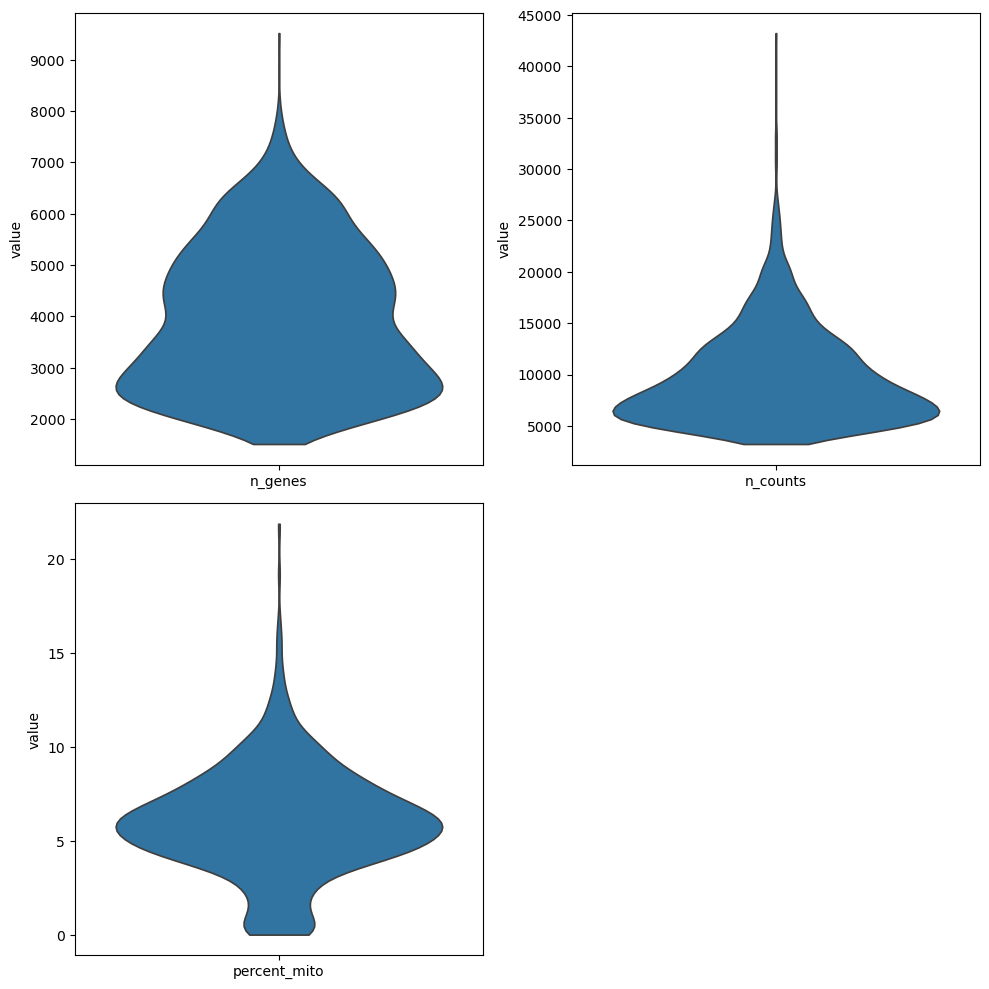

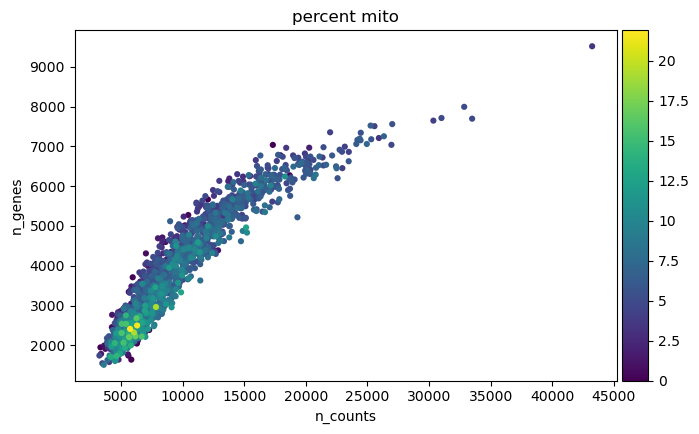

The 99th percentile all sample genes/cell is: 6394.0
The 99th percentile all sample total counts/cell is: 18521.149999999987
The 99th percentile all sample mitochondrial % /cell is: 10.592388891873465


In [11]:
## Plot QC Metrics ##

# QC by counts #
# convert to pegasus unimodal object
sawada_adata = UnimodalData(sawada_adata)
pg.qc_metrics(sawada_adata, mito_prefix='MT-')

# Create a figure with 3 subplots

# convert back for plotting to scanpy anndata
sawada_adata = sawada_adata.to_anndata()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sc.pl.violin(sawada_adata, "n_genes", ax=axes[0], show=False, stripplot=False)
sc.pl.violin(sawada_adata, "n_counts", ax=axes[1], show=False, stripplot=False)
sc.pl.violin(sawada_adata, "percent_mito", ax=axes[2], show=False, stripplot=False)
fig.delaxes(axes[3])
plt.tight_layout()

sc.pl.scatter(sawada_adata, "n_counts", "n_genes", color="percent_mito")

print('The 99th percentile all sample genes/cell is: {0}'.format(np.percentile(sawada_adata.obs['n_genes'], 95)))

print('The 99th percentile all sample total counts/cell is: {0}'.format(np.percentile(sawada_adata.obs['n_counts'], 95)))

print('The 99th percentile all sample mitochondrial % /cell is: {0}'.format(np.percentile(sawada_adata.obs['percent_mito'], 95)))

n_UMIs lower: 3114 upper: 23188
n_genes lower: 1512 upper: 9205


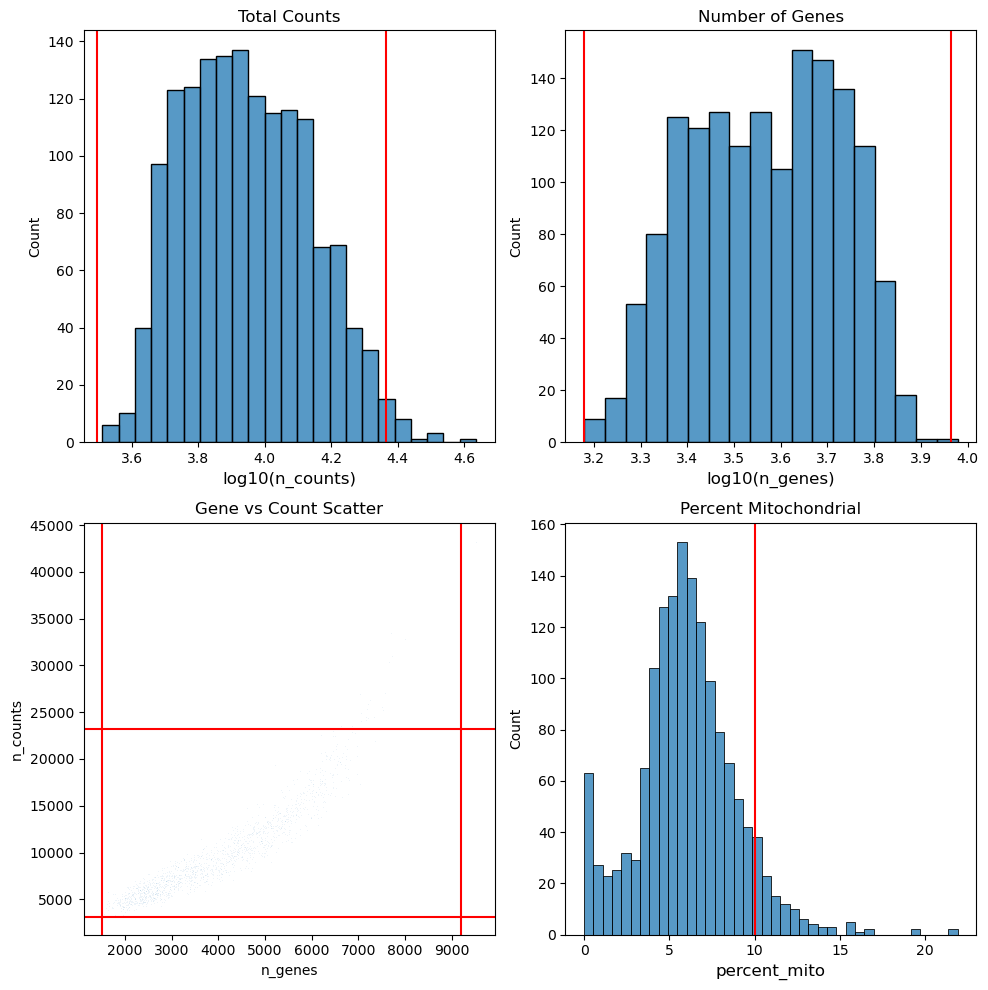

In [12]:
## Visualizating QC Cutoffs ##

MAD = 3

def qc_boundary(counts, k=MAD):
    x = np.log1p(counts)
    mad = median_abs_deviation(x)
    return np.exp(np.median(x) - k*mad), np.exp(np.median(x) + k*mad)

### nUMI and nGene QCs
n_counts_lower, n_counts_upper = qc_boundary(sawada_adata.obs.n_counts, k=MAD)
print('n_UMIs lower: %d upper: %d' % (n_counts_lower, n_counts_upper))

n_genes_lower, n_genes_upper = qc_boundary(sawada_adata.obs.n_genes, k=MAD)
print('n_genes lower: %d upper: %d' % (n_genes_lower, n_genes_upper))

## Plot Changes to Counts and Genes/Cell Distributions ##

fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # 2x2 grid, adjust size as needed

# Plot 1: log10(n_counts)
sns.histplot(np.log10(sawada_adata.obs.n_counts), ax=axs[0, 0])
axs[0, 0].axvline(np.log10(n_counts_lower), color='red')
axs[0, 0].axvline(np.log10(n_counts_upper), color='red')
axs[0, 0].set_xlabel('log10(n_counts)', fontsize=12)
axs[0, 0].set_title("Total Counts")

# Plot 2: log10(n_genes)
sns.histplot(np.log10(sawada_adata.obs.n_genes), ax=axs[0, 1])
axs[0, 1].axvline(np.log10(n_genes_lower), color='red')
axs[0, 1].axvline(np.log10(n_genes_upper), color='red')
axs[0, 1].set_xlabel('log10(n_genes)', fontsize=12)
axs[0, 1].set_title("Number of Genes")

# Plot 3: scatter plot of n_genes vs n_counts
sns.scatterplot(x=sawada_adata.obs.n_genes, y=sawada_adata.obs.n_counts, alpha=0.5, s=0.1, ax=axs[1, 0])
axs[1, 0].axhline(n_counts_lower, color='red')
axs[1, 0].axhline(n_counts_upper, color='red')
axs[1, 0].axvline(n_genes_lower, color='red')
axs[1, 0].axvline(n_genes_upper, color='red')
axs[1, 0].set_xlabel('n_genes')
axs[1, 0].set_ylabel('n_counts')
axs[1, 0].set_title("Gene vs Count Scatter")

# Plot 4: percent_mito
sns.histplot(sawada_adata.obs.percent_mito, ax=axs[1, 1])
axs[1, 1].axvline(10, color='red')
axs[1, 1].set_xlabel('percent_mito', fontsize=12)
axs[1, 1].set_title("Percent Mitochondrial")

plt.tight_layout()
plt.show()

n_cells before QC: 1508
n_cells after QC: 1508
mean n_cells before QC 188.5
mean n_cells after QC 188.5


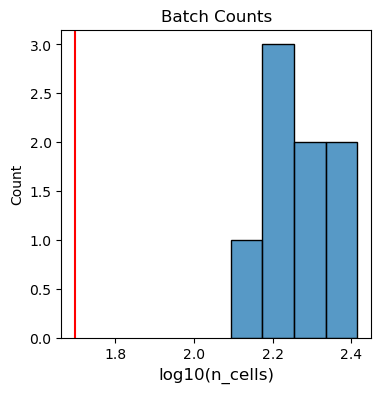

remove 0 batches that have cells less than 50


In [13]:
## Minimum Cell Cutoffs Based on Donor-Batches ##

args_min_n_cells = 50

n_cells_before_qc = sawada_adata.obs.library.value_counts().rename_axis('library').reset_index(name='counts')
n_cells_after_qc = sawada_adata.obs[sawada_adata.obs.passed_qc].library.value_counts().rename_axis('library').reset_index(name='counts')

print('n_cells before QC:', np.sum(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('n_cells after QC:', np.sum(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

print('mean n_cells before QC', np.mean(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('mean n_cells after QC', np.mean(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

# Plot Distribution of Donor-Batches on Being Greater than Zero
plt.figure(figsize=(4, 4))
plt.title('Batch Counts')
sns.histplot(np.log10(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
plt.axvline(np.log10(args_min_n_cells), color='red')
plt.xlabel('log10(n_cells)', fontsize=12)
plt.show()

### n_cells QC

#identify donor-batches with less than 50 cells of contribution
n_cells_outlier = list(n_cells_after_qc[n_cells_after_qc.counts<args_min_n_cells].library)
# set these to have failed QC as well
sawada_adata.obs.loc[sawada_adata.obs.library.isin(n_cells_outlier),'passed_qc'] = False
print('remove {0} batches that have cells less than {1}'.format(len(n_cells_outlier), args_min_n_cells))

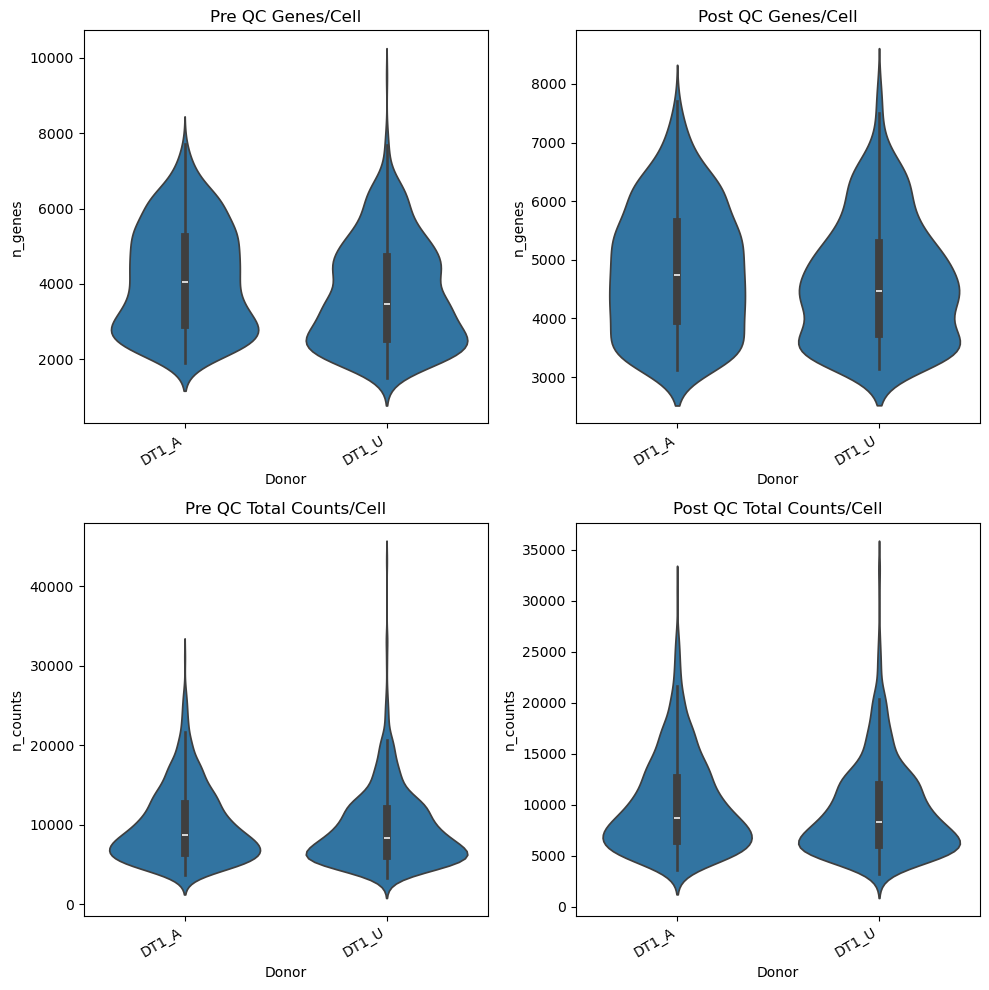

In [14]:
## Trialing QC Cutoffs Before and After ##

## Boolean Cutoffs for UMIs and Genes/Cell ##

counts_filter = (n_counts_lower < sawada_adata.obs.n_genes) & (sawada_adata.obs.n_genes < n_counts_upper)
genes_filter = (n_genes_lower < sawada_adata.obs.n_genes) & (sawada_adata.obs.n_genes < n_genes_upper)

# Plot Changes With Violins 

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sns.violinplot(data=sawada_adata.obs, y='n_genes', x='Donor', ax=axes[0])
axes[0].set_title('Pre QC Genes/Cell')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=sawada_adata.obs[counts_filter & genes_filter], x='Donor', y='n_genes', ax=axes[1])
axes[1].set_title('Post QC Genes/Cell')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=sawada_adata.obs, y='n_counts', x='Donor', ax=axes[2])
axes[2].set_title('Pre QC Total Counts/Cell')
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=sawada_adata.obs[sawada_adata.obs.passed_qc & genes_filter], x='Donor', y='n_counts', ax=axes[3])
axes[3].set_title('Post QC Total Counts/Cell')
plt.setp(axes[3].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

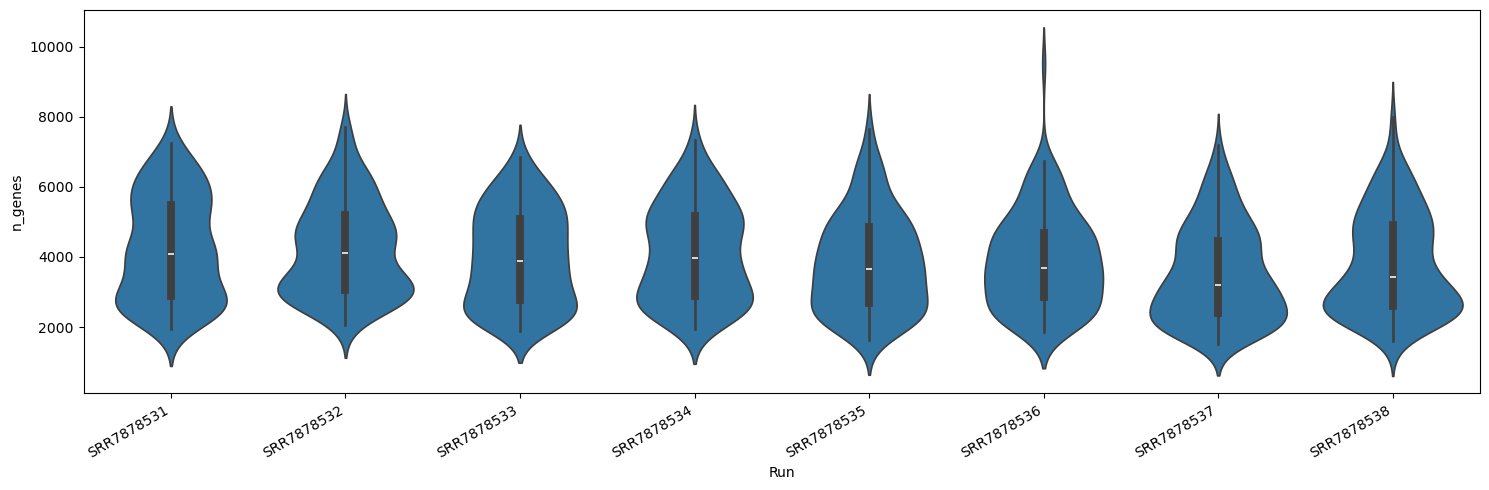

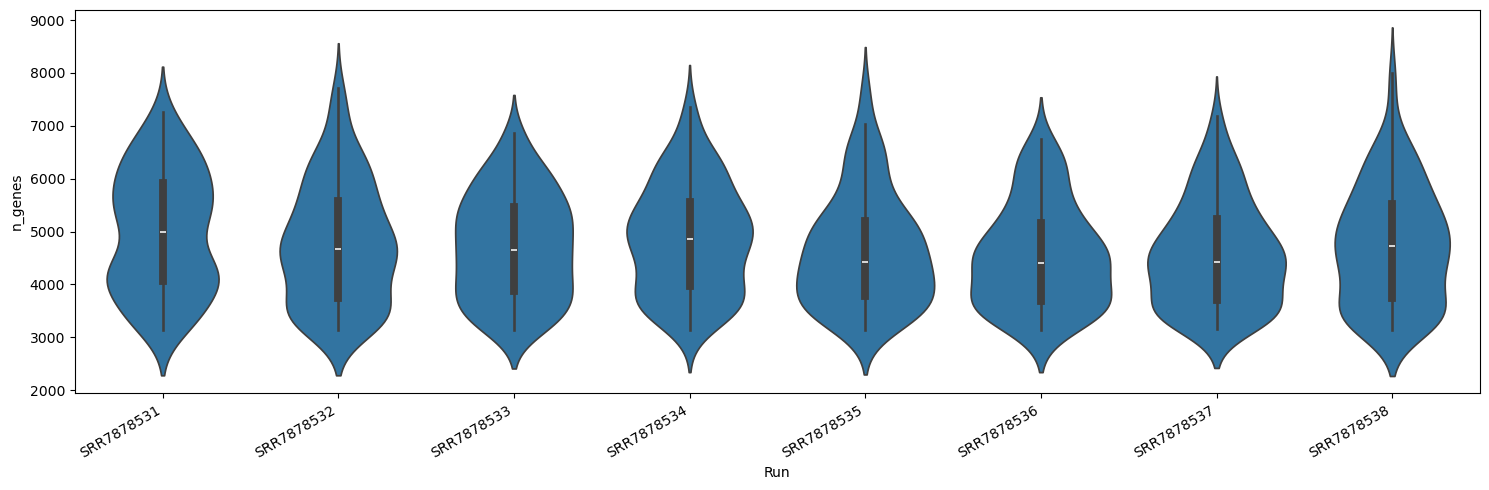

In [15]:
plt.figure(figsize=(15,5))
sns.violinplot(data=sawada_adata.obs, x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.figure(figsize=(15,5))
sns.violinplot(data=sawada_adata.obs[counts_filter & genes_filter], x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

In [16]:
## Remove Cells That Don't Meet Total Counts/Cell and Genes/Cell Thresholds ##

sawada_adata = MultimodalData(UnimodalData(sawada_adata, modality="rna"))

pg.qc_metrics(sawada_adata, 
              min_genes=n_genes_lower, max_genes=n_genes_upper,
              min_umis=n_counts_lower, max_umis=n_counts_upper,
              mito_prefix='MT-', percent_mito=10)

pg.filter_data(sawada_adata)
gc.collect()
sawada_adata = sawada_adata.to_anndata()

2026-03-03 10:55:05,804 - pegasusio.qc_utils - INFO - After filtration, 1372 out of 1508 cell barcodes are kept in UnimodalData object unknown-rna.
2026-03-03 10:55:05,804 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.15s.


In [17]:
## Filter Cells and Genes With Raw Cutoffs #

# store raw counts in layer
sawada_adata.layers["raw_counts"] = sawada_adata.X

# Note: No cells fail this cutoff affter using MAD based filtration
print((sawada_adata.obs.n_genes < 100).sum())
print((sawada_adata.var.n_cells < 20).any())

# Doing This For Completeness
sc.pp.filter_cells(sawada_adata, min_genes=100)
sc.pp.filter_genes(sawada_adata, min_cells=20)

0
True


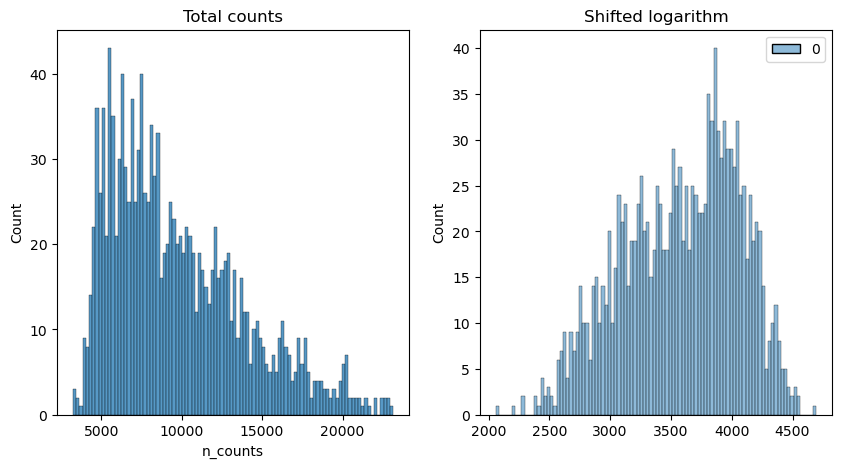

In [18]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(sawada_adata, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
sawada_adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
sawada_adata.X = sawada_adata.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(sawada_adata.obs["n_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(sawada_adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

2026-03-03 10:55:06,425 - pegasus.tools.utils - INFO - Loaded signatures from GMT file /home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pegasus/data_files/cell_cycle_human.gmt.
2026-03-03 10:55:06,427 - pegasus.tools.signature_score - INFO - Signature G1/S: 43 out of 43 genes are used in signature score calculation.
2026-03-03 10:55:06,436 - pegasus.tools.signature_score - INFO - Signature G2/M: 54 out of 54 genes are used in signature score calculation.
2026-03-03 10:55:06,484 - pegasus.tools.signature_score - INFO - Function 'calc_signature_score' finished in 0.09s.
2026-03-03 10:55:06,982 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 0.21s.


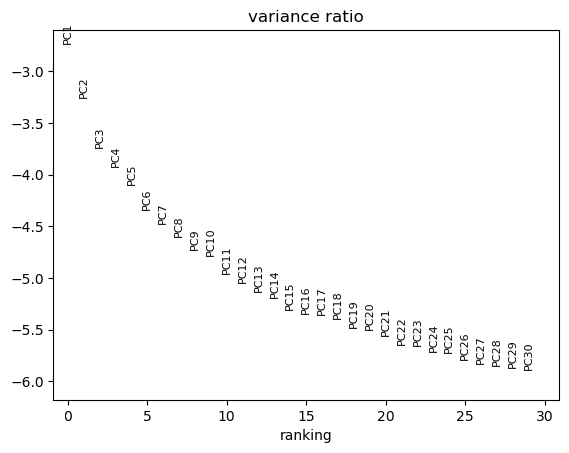

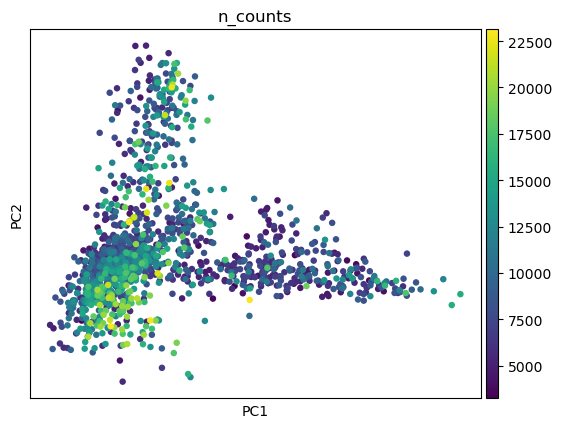

There is 29.939728290612422 variance explained by these components
2026-03-03 10:55:07,174 - pegasus.tools.preprocessing - INFO - Function 'regress_out' finished in 0.04s.
2026-03-03 10:55:07,175 - pegasus.tools.batch_correction - INFO - Start integration using Harmony.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
Reach convergence after 3 iteration(s).
2026-03-03 10:55:07,565 - pegasus.tools.batch_correction - INFO - Function 'run_harmony' finished in 0.39s.
2026-03-03 10:55:07,565 - pegasus.tools.nearest_neighbors - INFO - in get_neighbors, K is adjusted to 37.
2026-03-03 10:55:07,636 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.07s.
2026-03-03 10:55:07,651 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.01s.
2026-03-03 10:55:07,659 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 0.01s.
202

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Mar  3 10:55:08 2026 Finding Nearest Neighbors
Tue Mar  3 10:55:12 2026 Finished Nearest Neighbor Search
Tue Mar  3 10:55:13 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Mar  3 10:55:15 2026 Finished embedding
2026-03-03 10:55:15,053 - pegasus.tools.visualization - INFO - Function 'umap' finished in 7.37s.


In [19]:
# Calculate Highly Variable Genes (not using deviance) ##

if not isinstance(sawada_adata, UnimodalData):
    sawada_adata = UnimodalData(sawada_adata)

## ROUND 0 ##

# calc score requires a float downcast for some reason
sawada_adata.X = sawada_adata.X.astype('float32')
pg.calc_signature_score(sawada_adata, 'cell_cycle_human')

# calculate HVGs on a protein_coding_autosomal only gene list
sawada_hvg = sawada_adata[:,sawada_adata.var.robust_protein_coding_autosome].copy()
sawada_hvg = sawada_hvg.to_anndata()
hvg = sc.pp.highly_variable_genes(sawada_hvg, layer='log1p_norm', n_top_genes=3000, inplace=False, subset=False)
hvg_list = sawada_hvg.var.index[hvg.highly_variable].tolist()
del sawada_hvg
gc.collect()

# apply that HVG list to your original anndata object
sawada_adata.var['highly_variable_features'] = False
sawada_adata.var['highly_variable_features'] = sawada_adata.var.index.isin(hvg_list)

## Dimensionality Reduction ##

# PCA

if not isinstance(sawada_adata, UnimodalData):
    sawada_adata = UnimodalData(sawada_adata)

pg.pca(sawada_adata, n_components=30)
sc.pl.pca_variance_ratio(sawada_adata, n_pcs=30, log=True)
sc.pl.pca_scatter(sawada_adata.to_anndata(), color="n_counts")
plt.show()

print('There is {0} variance explained by these components'.format(sawada_adata.uns['pca']['variance_ratio'].sum()*100))

# # Regress Out ##

pg.regress_out(sawada_adata, ['n_counts', 'percent_mito'])

## Harmony  

pg.run_harmony(sawada_adata, batch=['Donor'], rep='pca_regressed', max_iter_harmony=20, n_comps=30)

# # UMAP

pg.neighbors(sawada_adata, rep='pca_regressed_harmony', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(sawada_adata, rep='pca_regressed_harmony', resolution=0.1, class_label='class')
pg.umap(sawada_adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)
plt.show()

sawada_adata = sawada_adata.to_anndata()

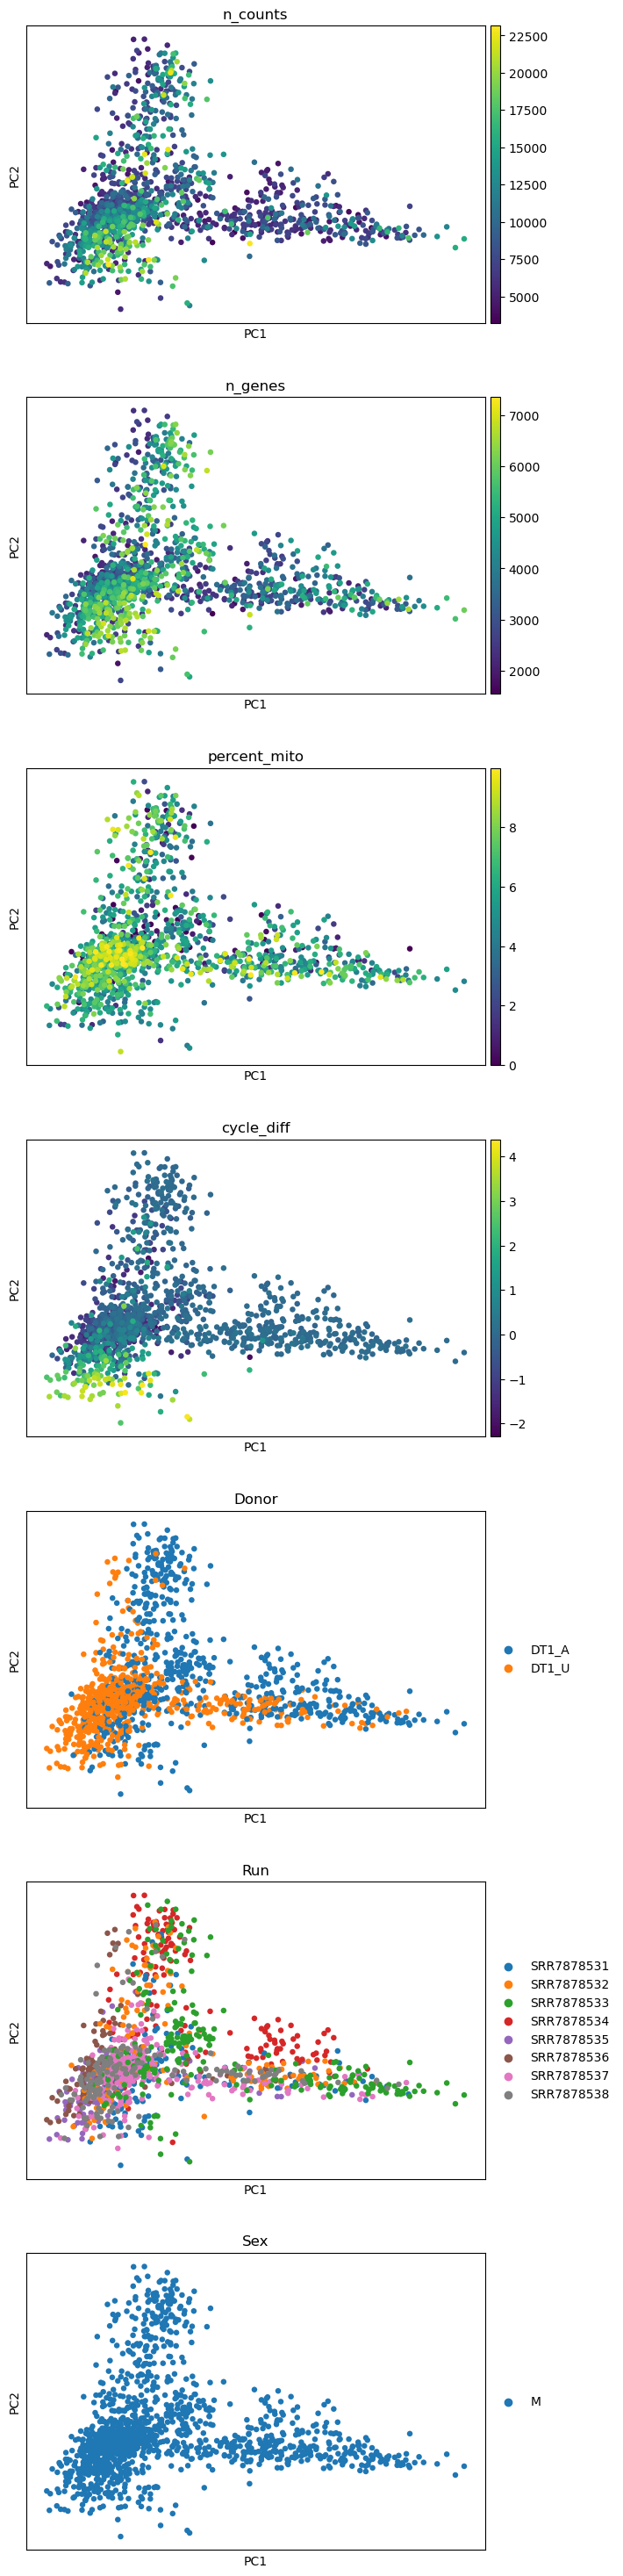

In [20]:
sc.pl.pca(sawada_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

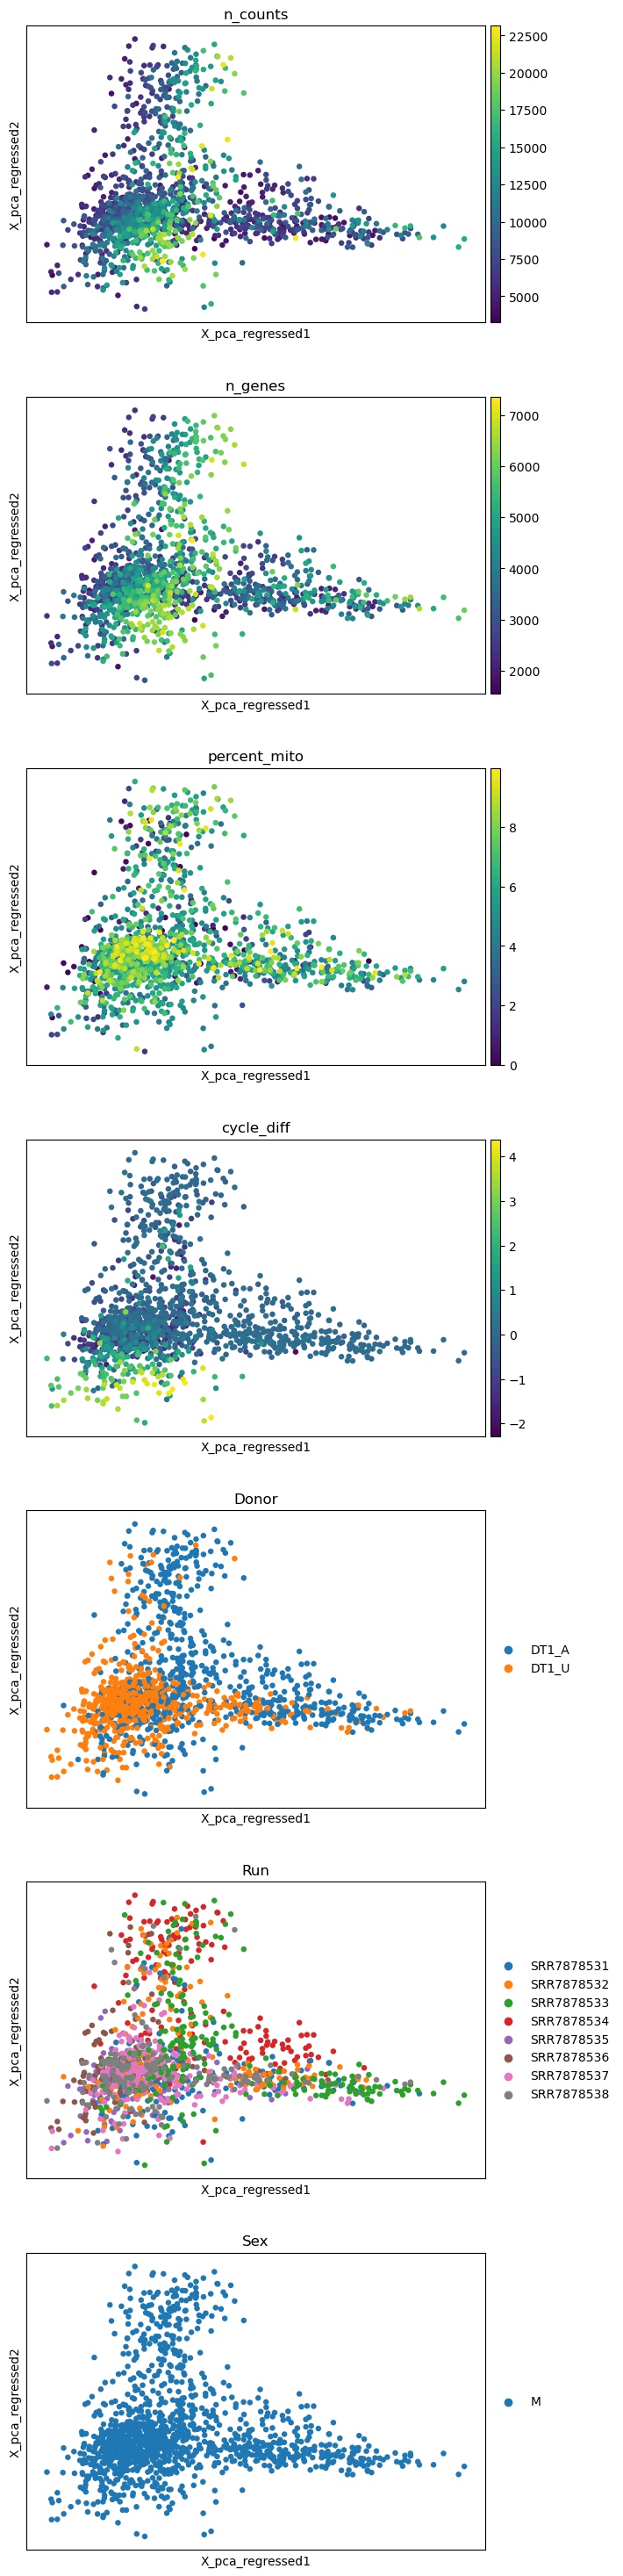

In [21]:
sc.pl.embedding(sawada_adata, basis='X_pca_regressed', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

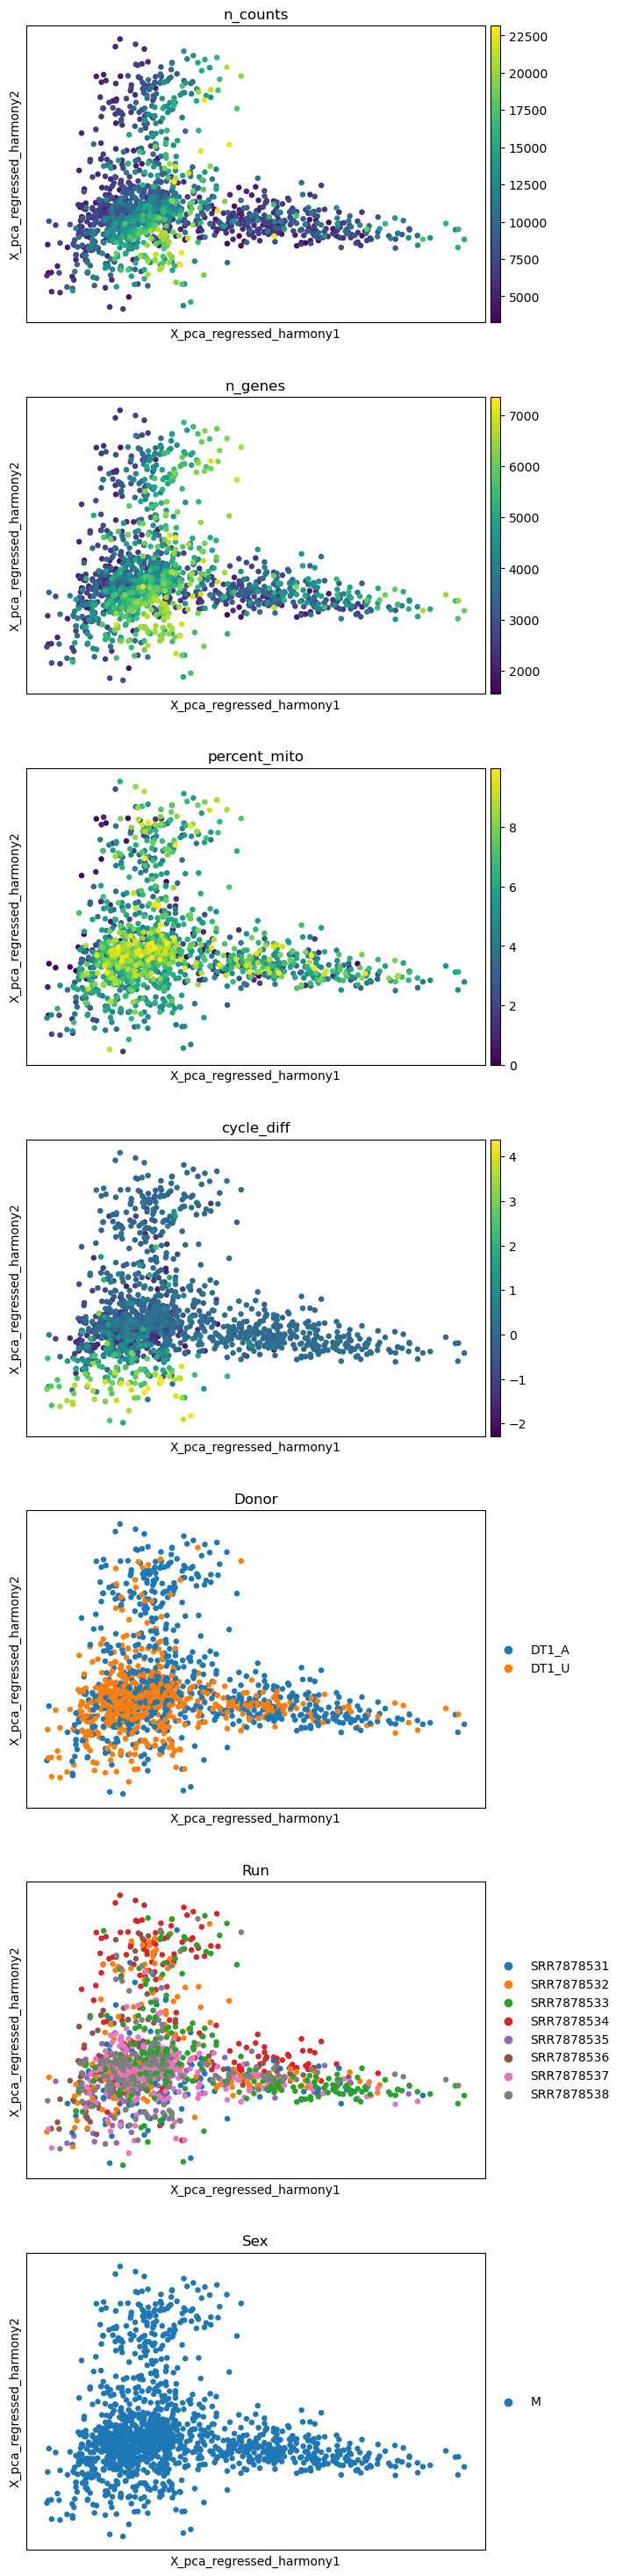

In [22]:
sc.pl.embedding(sawada_adata, basis='X_pca_regressed_harmony', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

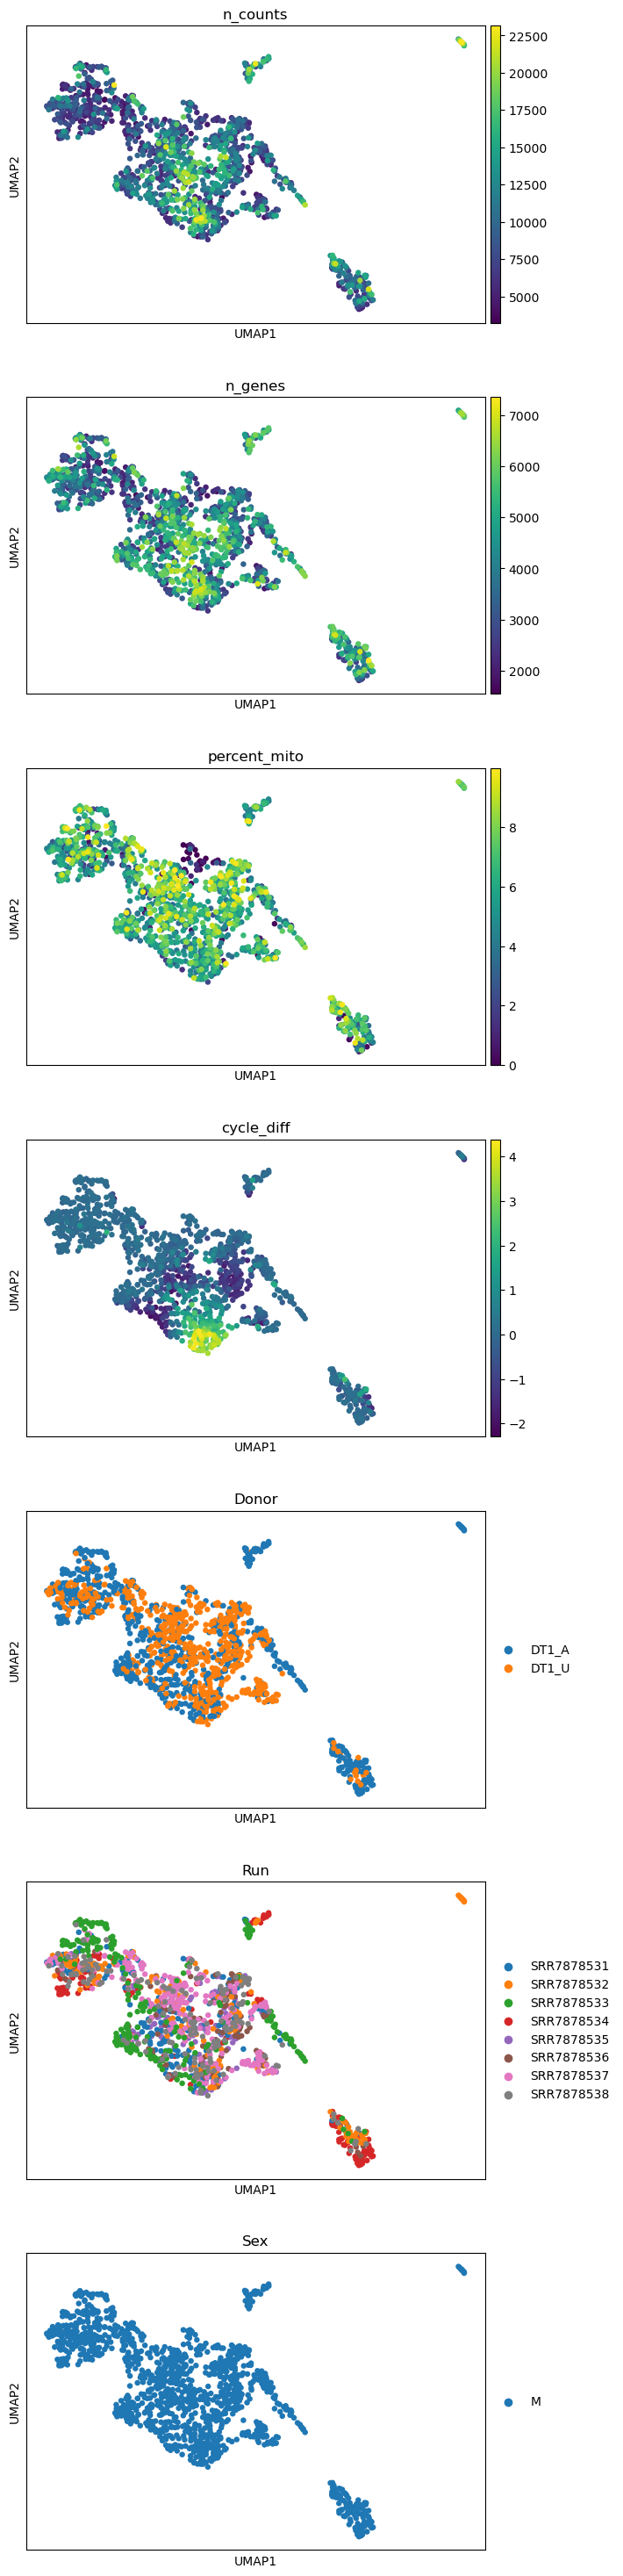

In [23]:
sc.pl.umap(sawada_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

In [24]:
sawada_adata.shape

(1372, 14162)

In [25]:
## Align Key Columns Across Datasets ##

sawada_adata.obs['Day'] = 35
sawada_adata.obs['Genotype'] = sawada_adata.obs['Diagnosis'].apply(lambda x: 'Idiopathic Schizophrenia' if x != 'Control' else x)
sawada_adata.obs['Manuscript'] = 'Sawada'
sawada_adata.obs['Protocol'] = 'Lancaster'
sawada_adata.obs['Whitelist'] = 'QuartzSeq2-Barcodes'
sawada_adata.obs['Chemistry'] = 'QuartzSeq2'

In [26]:
## Save Step ##

sawada_adata.write_h5ad(os.path.join('/mnt/sdb/scz_meta_analysis_processed/studies/sawada_kato/anndata_objs/sawada_qc.h5ad'))

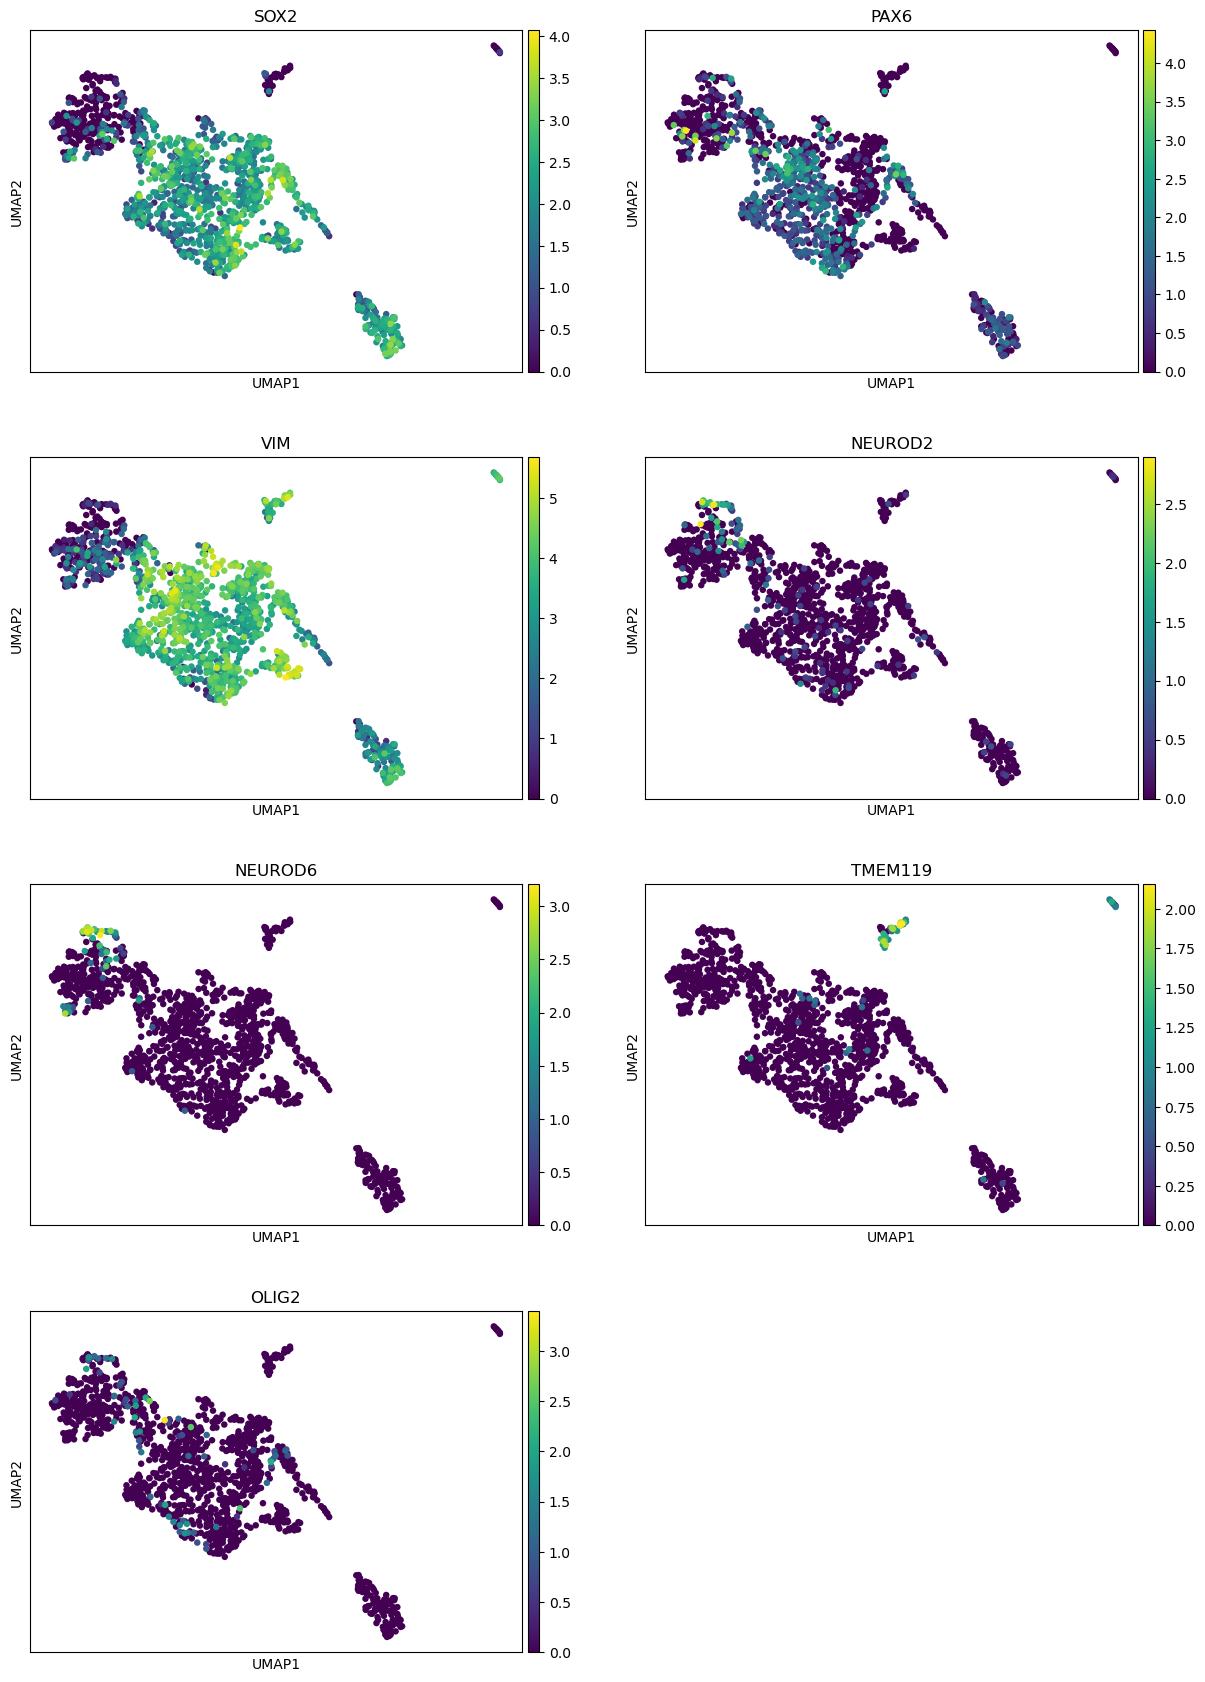

In [27]:
sc.pl.umap(sawada_adata, color=['SOX2', 'PAX6', 'VIM', 'NEUROD2', 'NEUROD6','TMEM119', 'OLIG2'], ncols=2)